### Data Loading and Preprocessing
This block imports necessary libraries, loads the previously cleaned dataset nasa_cleaned.csv, and performs the standard train/test split. It also scales the features using StandardScaler to prepare the data for the SVM model.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Load the pre-cleaned data from the EDA pipeline
df_cleaned = pd.read_csv('../data/nasa_cleaned.csv')

X = df_cleaned.drop('Hazardous', axis=1)
y = df_cleaned['Hazardous']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### SVM Hyperparameter Tuning
Here we define a parameter grid for our Support Vector Machine to test different combinations of `C`, `gamma`, and `kernel`. We employ `GridSearchCV` with 5-fold cross-validation, optimizing specifically for `recall` to reduce false negatives (classifying a hazardous asteroid as safe) and extract the highest performing model.

In [5]:

param_grid = {
    'C': [0.1, 1, 10, 100],  
    'gamma': ['scale', 'auto', 0.1, 0.01], 
    'kernel': ['rbf', 'linear'] 
}

base_svm = SVC(probability=True, random_state=42)

grid_search = GridSearchCV(base_svm, param_grid, cv=5, scoring='recall', verbose=1, n_jobs=-1)

grid_search.fit(X_train_scaled, y_train)

best_svm = grid_search.best_estimator_

print(f"Best Parameters Found: {grid_search.best_params_}")

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Parameters Found: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}


### Evaluation and Visualizations
In this final block, we make predictions using our best-found SVM model and evaluate it against the testing set. We print the numerical classification report and visually display the results utilizing a Confusion Matrix plot.

--- Classification Report ---
              precision    recall  f1-score   support

       False       0.97      0.98      0.98       787
        True       0.92      0.87      0.89       151

    accuracy                           0.97       938
   macro avg       0.95      0.93      0.94       938
weighted avg       0.97      0.97      0.97       938



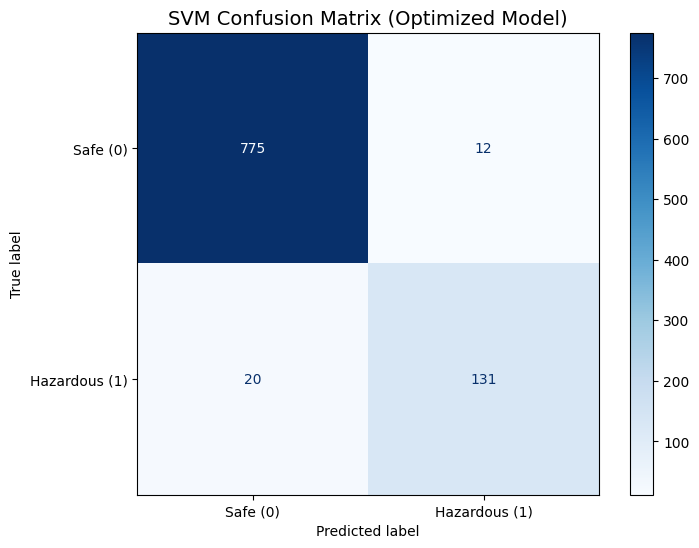

In [6]:

y_pred = best_svm.predict(X_test_scaled)

print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe (0)', 'Hazardous (1)'])

disp.plot(cmap='Blues', values_format='d', ax=plt.gca())

plt.title('SVM Confusion Matrix (Optimized Model)', fontsize=14)
plt.show()